# 05 — Weather Analysis

**Phase 7** of the blueprint: NOAA weather cleaning + weather-only EDA.

**Scope of this notebook:** clean the raw NOAA GHCN-Daily pull for station
`USW00094846` (O'Hare), engineer derived weather features, and understand
the weather data on its own terms (distributions, seasonality, trend,
extremes). Crime is **not** joined here — the crime x weather relationship
is Phase 8/10's job (notebook 06). This notebook's only output artifacts are
`data/interim/weather_cleaned.parquet` and the weather-side EDA findings that
feed Phase 18's threshold choices.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from src import config
from src.preprocessing.weather_cleaning import clean_weather_data
from src.features.weather_features import (
    create_weather_features,
    HEAVY_RAIN_THRESHOLD_IN,
    HEAVY_SNOW_THRESHOLD_IN,
    EXTREME_HEAT_THRESHOLD_F,
    EXTREME_COLD_THRESHOLD_F,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)

RAW_WEATHER_PATH = config.DATA_RAW / "weather" / "weather_raw_2021_2025.parquet"
INTERIM_WEATHER_PATH = config.DATA_INTERIM / "weather_cleaned.parquet"
config.DATA_INTERIM.mkdir(parents=True, exist_ok=True)

RAW_WEATHER_PATH

WindowsPath('C:/Users/Tarankit/Documents/Code/spatial-temporal-crime-trajectory-analytics/data/raw/weather/weather_raw_2021_2025.parquet')

## 1. Load raw NOAA extract

Raw file is untouched — loaded read-only, never mutated on disk (blueprint
rule: raw data immutable). This is the same file `01_data_ingestion_and_quality`
pulled and validated at the schema level; here we re-load it independently so
this notebook is runnable on its own.

In [2]:
raw = pd.read_parquet(RAW_WEATHER_PATH)
print(f"shape: {raw.shape}")
raw.head()

shape: (1826, 7)


,DATE,AWND,STATION,SNOW,TMAX,TMIN,PRCP
0,2021-01-01,11.86,USW00094846,1.3,35,19,0.38
1,2021-01-02,6.26,USW00094846,0.0,35,28,0.00
2,2021-01-03,6.93,USW00094846,0.4,33,26,0.03
3,2021-01-04,7.83,USW00094846,0.0,30,24,0.00
4,2021-01-05,5.59,USW00094846,0.0,37,29,0.00


In [3]:
raw.dtypes.to_frame("dtype")

,dtype
DATE,object
AWND,object
STATION,object
SNOW,object
TMAX,object
TMIN,object
PRCP,object


## 2. Clean via `preprocessing.weather_cleaning`

Reusable logic lives in `src/`; this notebook orchestrates and explains only
(blueprint rule 14). `clean_weather_data` normalizes `DATE`/`STATION` -> lower
case merge-key convention, coerces the six numeric columns, replaces NOAA
sentinel values with `NaN`, drops exact-duplicate rows, and **raises** if two
distinct rows still claim the same date — that's a data-integrity problem for
a human to resolve, not something to silently pick a winner on.

Full audit trail (raw -> transform -> removed/flagged -> final) is returned
alongside the cleaned frame, not hidden.

In [4]:
weather_clean, audit = clean_weather_data(raw)
audit

{'raw_rows': 1826,
 'sentinel_values_replaced': {'TMAX': 0,
  'TMIN': 0,
  'PRCP': 0,
  'SNOW': 0,
  'AWND': 0},
 'duplicate_rows_dropped': 0,
 'implausible_temp_rows': 0,
 'final_rows': 1826}

In [5]:
weather_clean.dtypes.to_frame("dtype")

,dtype
date,object
AWND,float64
station,object
SNOW,float64
TMAX,int64
TMIN,int64
PRCP,float64


### 2.1 Reading the audit

- **`raw_rows` -> `final_rows`**: every row survives cleaning here — no dupes,
  no sentinel rows removed outright (sentinels become targeted `NaN`s within
  a row, not row deletions).
- **`sentinel_values_replaced`**: per-column count of `-9999`-family values
  swapped for `NaN`. Zero across the board on this pull — station
  `USW00094846` reported cleanly for 2021–2025 on the six variables we asked
  for.
- **`implausible_temp_rows`**: count of rows where `TMAX < TMIN`, flagged but
  **not altered** by the cleaning step (documented deferral to this notebook,
  same reasoning `crime_cleaning` uses for coordinate nulls — decide with the
  full distribution in view, not blind).

In [6]:
assert audit["implausible_temp_rows"] == 0, "implausible TMAX<TMIN rows present -- inspect before proceeding"
print("No TMAX < TMIN rows -- temperature pair is internally consistent for all 1,826 days.")

No TMAX < TMIN rows -- temperature pair is internally consistent for all 1,826 days.


### 2.2 Date coverage check

`config.START_DATE` / `config.END_DATE` define the fixed 2021–2025 scope.
Confirm the cleaned frame has exactly one row per calendar day in that
window, with no gaps — a gap here would silently bias any later daily
merge with the crime data (Phase 8).

In [7]:
expected_dates = pd.date_range(config.START_DATE, config.END_DATE, freq="D")
actual_dates = pd.to_datetime(weather_clean["date"]).sort_values()

missing_dates = expected_dates.difference(actual_dates)
extra_dates = actual_dates[~actual_dates.isin(expected_dates)]

print(f"expected days : {len(expected_dates)}")
print(f"actual days   : {len(actual_dates)}")
print(f"missing days  : {len(missing_dates)}")
print(f"out-of-scope days: {len(extra_dates)}")

if len(missing_dates):
    print(missing_dates)
if len(extra_dates):
    print(extra_dates)

expected days : 1826
actual days   : 1826
missing days  : 0
out-of-scope days: 0


In [8]:
assert len(missing_dates) == 0, "gap(s) in daily weather coverage -- must resolve before crime merge (Phase 8)"
assert len(extra_dates) == 0, "rows outside 2021-2025 scope -- filter before persisting"
assert weather_clean["date"].is_unique
print("Coverage confirmed: exactly one row per day, 2021-01-01 through 2025-12-31, zero gaps.")

Coverage confirmed: exactly one row per day, 2021-01-01 through 2025-12-31, zero gaps.


### 2.3 `station` sanity check

Single-station design (blueprint limitation, stated explicitly): one O'Hare
reading approximates weather for every community area citywide. Confirm the
cleaned data really is single-station before that assumption gets baked into
downstream merges.

In [9]:
station_counts = weather_clean["station"].value_counts()
station_counts

station
USW00094846    1826
Name: count, dtype: int64

In [10]:
assert (weather_clean["station"] == config.NOAA_STATION_ID).all(), "unexpected station id present"
print(f"Confirmed single station: {config.NOAA_STATION_ID} across all {len(weather_clean)} rows.")

Confirmed single station: USW00094846 across all 1826 rows.


## 3. Derived features via `features.weather_features`

`create_weather_features` adds `avg_temp`, `temp_range`, and five documented
threshold flags. No composite/weighted "weather score" — each flag stands
alone and its threshold is named and sourced in the module docstring
(blueprint rule: no undocumented composite score).

Confirmed in `01_data_ingestion_and_quality`: this station's extract has **no
`TAVG` column** at all (not just nulls — the field is entirely absent), so
`avg_temp` is `(TMAX + TMIN) / 2` for all 1,826 rows. That's a computed value,
not a station reading — documented here and in the module, not glossed over.

In [11]:
"TAVG" in weather_clean.columns

False

In [12]:
weather = create_weather_features(weather_clean)
weather = weather.sort_values("date").reset_index(drop=True)
weather["date"] = pd.to_datetime(weather["date"])
weather.head()

,date,AWND,station,SNOW,TMAX,TMIN,PRCP,avg_temp,temp_range,is_rain,is_snow,is_heavy_rain,is_heavy_snow,is_extreme_heat,is_extreme_cold
0,2021-01-01,11.86,USW00094846,1.3,35,19,0.38,27.0,16,True,True,False,False,False,True
1,2021-01-02,6.26,USW00094846,0.0,35,28,0.00,31.5,7,False,False,False,False,False,False
2,2021-01-03,6.93,USW00094846,0.4,33,26,0.03,29.5,7,True,True,False,False,False,False
3,2021-01-04,7.83,USW00094846,0.0,30,24,0.00,27.0,6,False,False,False,False,False,False
4,2021-01-05,5.59,USW00094846,0.0,37,29,0.00,33.0,8,False,False,False,False,False,False


In [13]:
print("avg_temp source: 100% computed as (TMAX+TMIN)/2 -- TAVG column absent from this station's extract.")
print()
print("Threshold constants in force:")
print(f"  HEAVY_RAIN_THRESHOLD_IN  = {HEAVY_RAIN_THRESHOLD_IN}")
print(f"  HEAVY_SNOW_THRESHOLD_IN  = {HEAVY_SNOW_THRESHOLD_IN}")
print(f"  EXTREME_HEAT_THRESHOLD_F = {EXTREME_HEAT_THRESHOLD_F}")
print(f"  EXTREME_COLD_THRESHOLD_F = {EXTREME_COLD_THRESHOLD_F}")

avg_temp source: 100% computed as (TMAX+TMIN)/2 -- TAVG column absent from this station's extract.

Threshold constants in force:
  HEAVY_RAIN_THRESHOLD_IN  = 1.0
  HEAVY_SNOW_THRESHOLD_IN  = 4.0
  EXTREME_HEAT_THRESHOLD_F = 90.0
  EXTREME_COLD_THRESHOLD_F = 20.0


In [14]:
flag_cols = ["is_rain", "is_snow", "is_heavy_rain", "is_heavy_snow", "is_extreme_heat", "is_extreme_cold"]
flag_rates = weather[flag_cols].mean().rename("share_of_days").to_frame()
flag_rates["n_days"] = weather[flag_cols].sum().values
flag_rates

,share_of_days,n_days
is_rain,0.333516,609
is_snow,0.070646,129
is_heavy_rain,0.015882,29
is_heavy_snow,0.004381,8
is_extreme_heat,0.059693,109
is_extreme_cold,0.102957,188


**Reading the flags against the thresholds chosen:** `is_heavy_rain` and
`is_heavy_snow` are meant to be rare-tail flags — if either fires on a large
share of days, the threshold is miscalibrated for this climate and needs
revisiting *before* Phase 18, not after modeling shows a useless feature.

In [15]:
for col, thresh_name in [("is_heavy_rain", "1 in/day"), ("is_heavy_snow", "4 in/day")]:
    rate = weather[col].mean()
    flag = "narrow tail -- as intended" if rate < 0.05 else "WIDE -- revisit threshold before Phase 18"
    print(f"{col:16s} ({thresh_name:8s}): {rate:.2%} of days -> {flag}")

is_heavy_rain    (1 in/day): 1.59% of days -> narrow tail -- as intended
is_heavy_snow    (4 in/day): 0.44% of days -> narrow tail -- as intended


## 4. Data quality scan

Tier-1/2 checks the cleaning step already enforces (no missing dates, no
duplicate dates, no sentinels, `TMAX >= TMIN`) are confirmed above. This
section covers what cleaning intentionally leaves for EDA to characterize:
full univariate quality per numeric column, not just pass/fail gates.

In [16]:
numeric_cols = ["TMAX", "TMIN", "avg_temp", "temp_range", "PRCP", "SNOW", "AWND"]

quality_rows = []
for col in numeric_cols:
    s = weather[col]
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = ((s < lo) | (s > hi)).sum()
    quality_rows.append({
        "column": col,
        "missing_pct": round(s.isna().mean() * 100, 2),
        "min": round(s.min(), 2),
        "p25": round(q1, 2),
        "median": round(s.median(), 2),
        "p75": round(q3, 2),
        "max": round(s.max(), 2),
        "mean": round(s.mean(), 2),
        "std": round(s.std(), 2),
        "skew": round(stats.skew(s.dropna()), 2),
        "iqr_outliers": outliers,
        "iqr_outlier_pct": round(outliers / len(s) * 100, 2),
    })

quality_df = pd.DataFrame(quality_rows).set_index("column")
quality_df

,missing_pct,min,p25,median,p75,max,mean,std,skew,iqr_outliers,iqr_outlier_pct
column,,,,,,,,,,,
TMAX,0.0,-1.00,45.00,64.00,80.00,100.00,61.65,20.86,-0.34,0,0.00
TMIN,0.0,-10.00,32.00,45.00,62.00,80.00,44.85,18.69,-0.36,0,0.00
avg_temp,0.0,-4.50,38.00,54.25,70.50,87.50,53.25,19.52,-0.35,0,0.00
temp_range,0.0,2.00,12.00,17.00,21.00,43.00,16.80,6.68,0.26,6,0.33
PRCP,0.0,0.00,0.00,0.00,0.03,3.35,0.09,0.25,4.87,368,20.15
SNOW,0.0,0.00,0.00,0.00,0.00,8.40,0.09,0.51,8.75,129,7.06
AWND,0.0,2.24,6.93,9.17,11.41,27.96,9.47,3.38,0.64,22,1.20


**Reading the quality table:**
- `PRCP` and `SNOW` are heavily right-skewed by construction (most days are
  dry) — the IQR-outlier count on those two columns is expected structure
  (rain/snow *events*), not data error, and should not be treated as
  candidates for removal.
- `temp_range` and `AWND` skew close to symmetric — any IQR outliers there
  are worth a closer look since there's no seasonal "mostly zero" floor
  explaining them the way there is for precipitation.

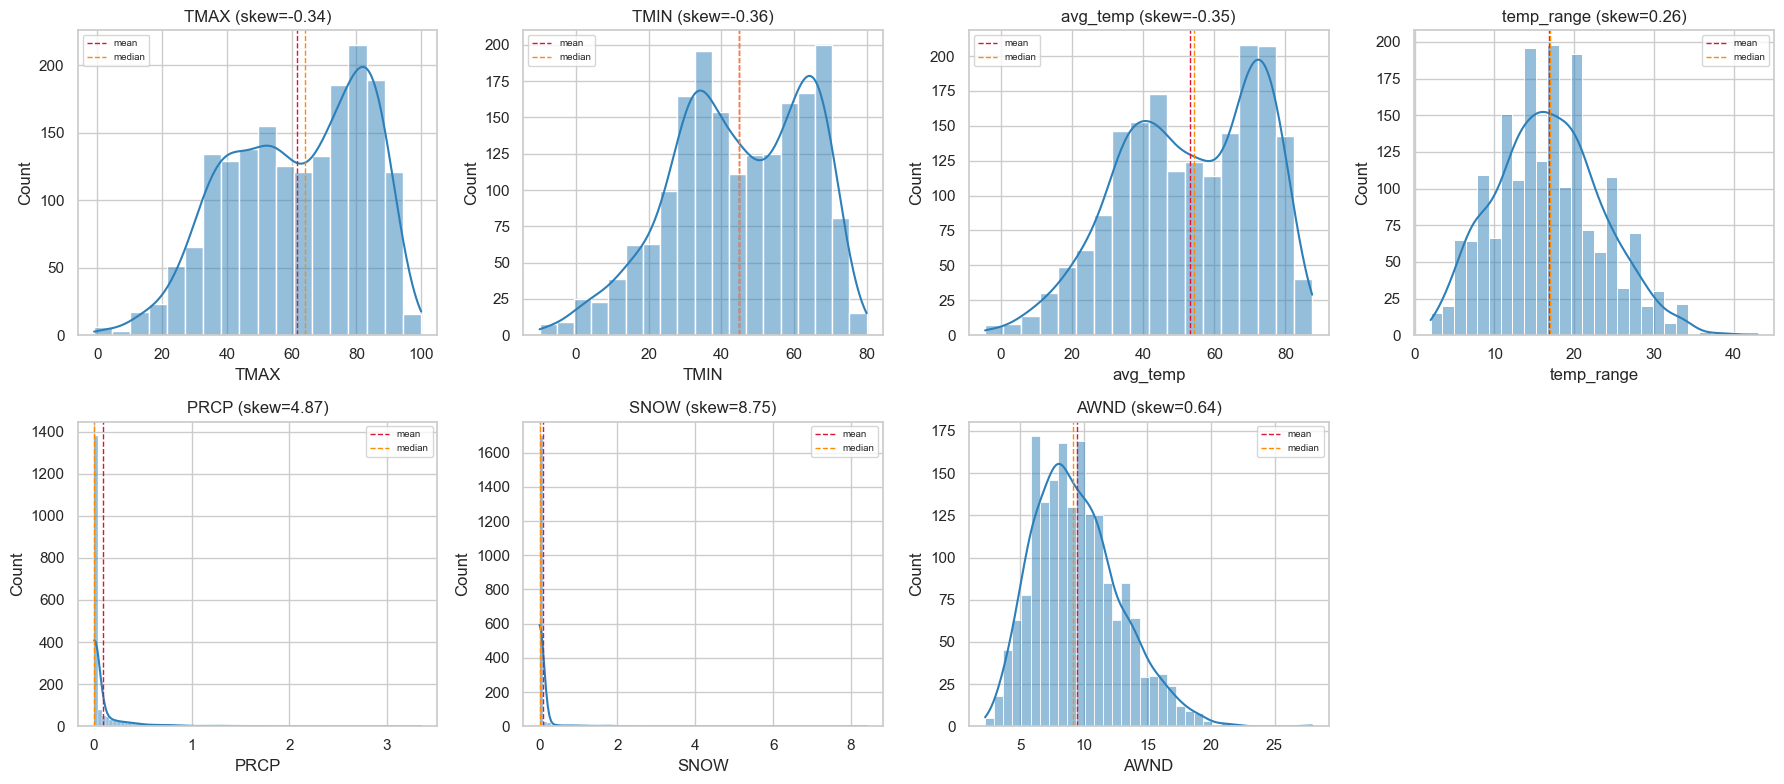

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.histplot(weather[col], kde=True, ax=ax, color="#2c7fb8")
    ax.axvline(weather[col].mean(), color="crimson", ls="--", lw=1, label="mean")
    ax.axvline(weather[col].median(), color="darkorange", ls="--", lw=1, label="median")
    ax.set_title(f"{col} (skew={stats.skew(weather[col].dropna()):.2f})")
    ax.legend(fontsize=7)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

## 5. Seasonality and calendar structure

Weather EDA framed around one analytical question per plot (blueprint rule:
no plots without an analytical question behind them): **how do temperature,
precipitation, and snowfall move through the year, and is that pattern
stable across 2021–2025, or drifting?**

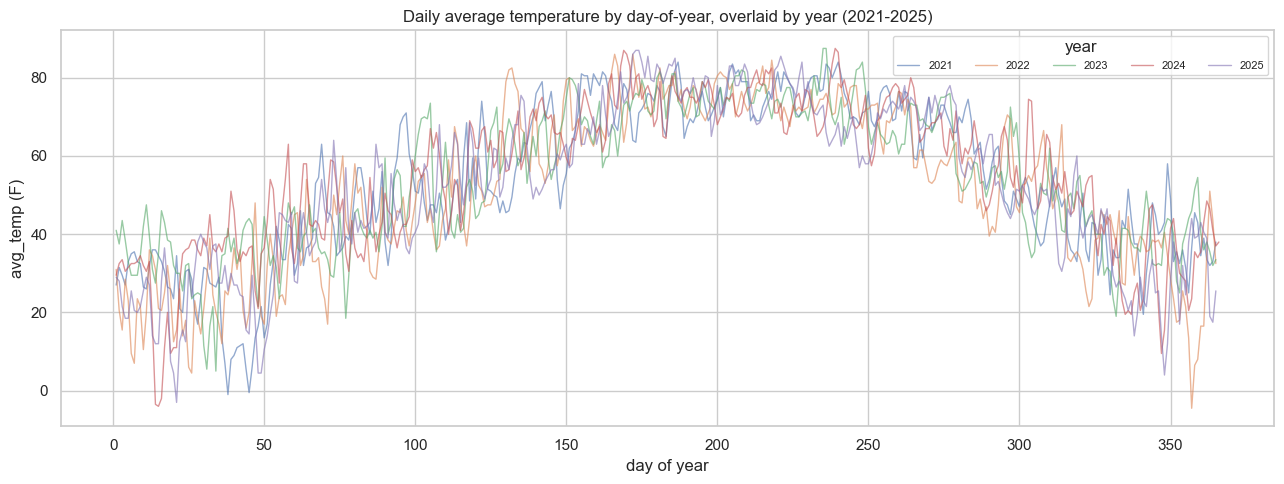

In [18]:
weather["year"] = weather["date"].dt.year
weather["month"] = weather["date"].dt.month
weather["doy"] = weather["date"].dt.dayofyear

fig, ax = plt.subplots(figsize=(13, 5))
for yr, grp in weather.groupby("year"):
    ax.plot(grp["doy"], grp["avg_temp"], alpha=0.6, lw=1, label=str(yr))
ax.set_xlabel("day of year")
ax.set_ylabel("avg_temp (F)")
ax.set_title("Daily average temperature by day-of-year, overlaid by year (2021-2025)")
ax.legend(title="year", ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

In [19]:
monthly = weather.groupby("month").agg(
    avg_temp_mean=("avg_temp", "mean"),
    avg_temp_std=("avg_temp", "std"),
    prcp_mean=("PRCP", "mean"),
    snow_mean=("SNOW", "mean"),
    rain_day_rate=("is_rain", "mean"),
    snow_day_rate=("is_snow", "mean"),
)
monthly

,avg_temp_mean,avg_temp_std,prcp_mean,snow_mean,rain_day_rate,snow_day_rate
month,,,,,,
1,26.187097,10.406533,0.070129,0.428387,0.412903,0.329032
2,29.695035,12.399420,0.062695,0.313475,0.312057,0.219858
3,42.441935,8.956416,0.098839,0.072258,0.380645,0.077419
4,50.830000,9.574475,0.094467,0.006000,0.400000,0.033333
5,61.845161,9.078941,0.073419,0.000000,0.309677,0.000000
6,73.096667,7.055793,0.123533,0.000000,0.360000,0.000000
7,75.548387,4.480758,0.156065,0.000000,0.361290,0.000000
8,74.780645,5.466273,0.100129,0.000000,0.245161,0.000000
9,69.396667,6.255279,0.057333,0.000000,0.266667,0.000000


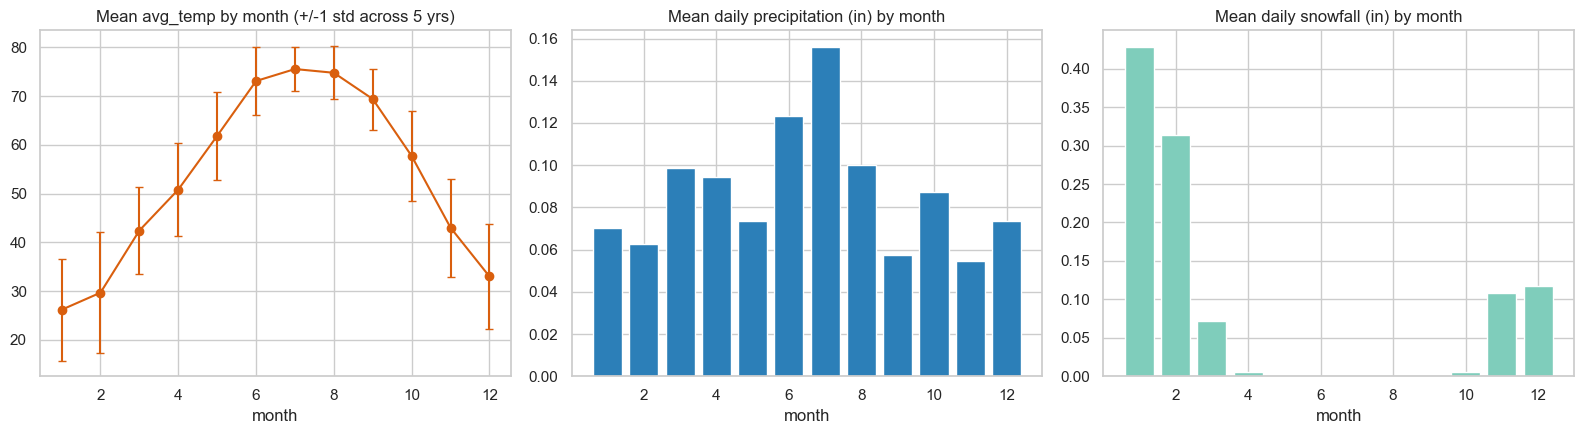

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].errorbar(monthly.index, monthly["avg_temp_mean"], yerr=monthly["avg_temp_std"],
                  fmt="-o", color="#d95f0e", capsize=3)
axes[0].set_title("Mean avg_temp by month (+/-1 std across 5 yrs)")
axes[0].set_xlabel("month")

axes[1].bar(monthly.index, monthly["prcp_mean"], color="#2c7fb8")
axes[1].set_title("Mean daily precipitation (in) by month")
axes[1].set_xlabel("month")

axes[2].bar(monthly.index, monthly["snow_mean"], color="#7fcdbb")
axes[2].set_title("Mean daily snowfall (in) by month")
axes[2].set_xlabel("month")

plt.tight_layout()
plt.show()

**Reading:** temperature follows the expected Midwest sinusoid (trough
Jan, peak Jul); snowfall concentrated Nov–Mar with a near-zero summer floor;
precipitation is comparatively flat across months with a mild spring/summer
lift — worth a formal test rather than eyeballing (next section).

### 5.1 Year-over-year drift check

Blueprint asks whether spatial *crime* patterns change over time (Phase 9);
the weather-side equivalent is checking whether the climate itself drifted
across the 5-year window, since a drifting weather baseline would complicate
attributing any crime-model instability to crime-side causes alone.

In [21]:
yearly = weather.groupby("year").agg(
    avg_temp_mean=("avg_temp", "mean"),
    prcp_total=("PRCP", "sum"),
    snow_total=("SNOW", "sum"),
    extreme_heat_days=("is_extreme_heat", "sum"),
    extreme_cold_days=("is_extreme_cold", "sum"),
)
yearly

,avg_temp_mean,prcp_total,snow_total,extreme_heat_days,extreme_cold_days
year,,,,,
2021,53.521918,30.15,47.2,22,31
2022,51.391781,31.99,35.2,16,58
2023,54.138356,33.73,19.8,21,20
2024,54.976776,34.92,23.6,23,27
2025,52.198630,29.79,32.2,27,52


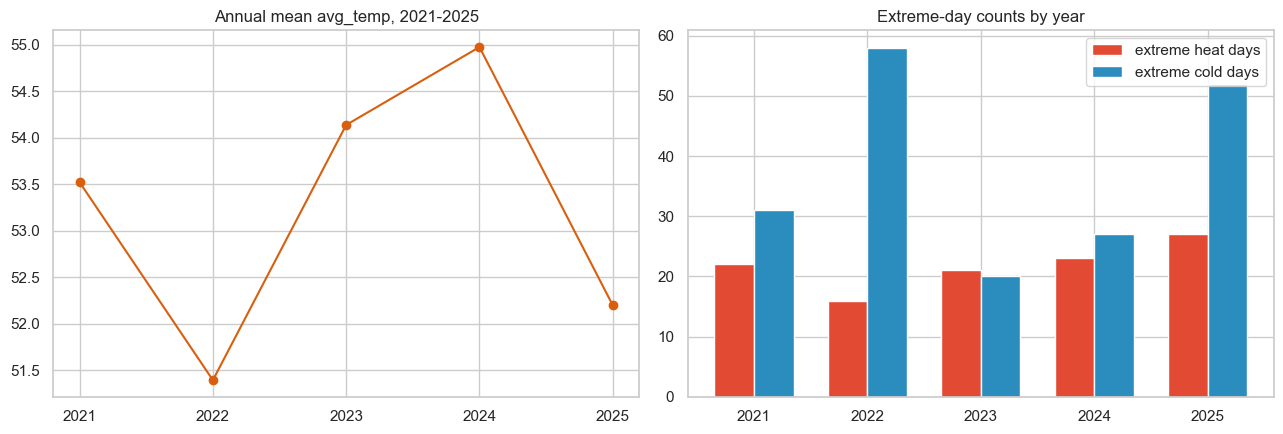

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(yearly.index, yearly["avg_temp_mean"], "-o", color="#d95f0e")
axes[0].set_title("Annual mean avg_temp, 2021-2025")
axes[0].set_xticks(yearly.index)

width = 0.35
axes[1].bar(yearly.index - width/2, yearly["extreme_heat_days"], width, label="extreme heat days", color="#e34a33")
axes[1].bar(yearly.index + width/2, yearly["extreme_cold_days"], width, label="extreme cold days", color="#2b8cbe")
axes[1].set_title("Extreme-day counts by year")
axes[1].set_xticks(yearly.index)
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Formal seasonal tests + effect sizes

Eyeballing the monthly chart suggests temperature and snowfall vary strongly
by month; precipitation less obviously so. Tier-3 depth means backing that
with a formal test and an effect size, not just the chart (blueprint
language rule applies here too: report association, not causation — season
doesn't "cause" temperature, it's definitionally linked to it, but the test
still quantifies how much of the variance month explains).

In [23]:
def eta_squared(groups):
    """Effect size for one-way ANOVA/Kruskal-Wallis: SS_between / SS_total."""
    all_vals = np.concatenate(groups)
    grand_mean = all_vals.mean()
    ss_total = ((all_vals - grand_mean) ** 2).sum()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    return ss_between / ss_total

results = []
for col in ["avg_temp", "PRCP", "SNOW", "AWND"]:
    groups = [g[col].dropna().values for _, g in weather.groupby("month")]
    # Normality is doubtful for PRCP/SNOW (zero-inflated) -- use Kruskal-Wallis
    # (distribution-appropriate, per blueprint rule) rather than assuming ANOVA fits.
    h_stat, p_val = stats.kruskal(*groups)
    eff = eta_squared(groups)
    results.append({"variable": col, "test": "Kruskal-Wallis", "H": round(h_stat, 1),
                     "p_value": p_val, "eta_squared": round(eff, 3)})

seasonal_test_df = pd.DataFrame(results)
seasonal_test_df

,variable,test,H,p_value,eta_squared
0,avg_temp,Kruskal-Wallis,1477.1,2.724779e-310,0.793
1,PRCP,Kruskal-Wallis,21.1,3.206094e-02,0.013
2,SNOW,Kruskal-Wallis,287.5,3.740381e-55,0.071
3,AWND,Kruskal-Wallis,188.6,1.703760e-34,0.102


**Interpretation:** `eta_squared` here is the share of variance in the
variable explained by calendar month — this is an *association* strength
(month explains temperature by definition of season, not the other way
round), reported as a magnitude, not a causal claim.

In [24]:
for _, row in seasonal_test_df.iterrows():
    strength = "large" if row["eta_squared"] >= 0.14 else ("medium" if row["eta_squared"] >= 0.06 else "small")
    sig = "significant" if row["p_value"] < 0.05 else "not significant"
    print(f"{row['variable']:10s}: month explains {row['eta_squared']:.1%} of variance "
          f"({strength} effect, {sig}, p={row['p_value']:.2e})")

avg_temp  : month explains 79.3% of variance (large effect, significant, p=2.72e-310)
PRCP      : month explains 1.3% of variance (small effect, significant, p=3.21e-02)
SNOW      : month explains 7.1% of variance (medium effect, significant, p=3.74e-55)
AWND      : month explains 10.2% of variance (medium effect, significant, p=1.70e-34)


### 6.1 Weekday vs weekend — is there a weather-collection artifact?

Not an expected physical effect, but a sanity check the blueprint's Phase 18
interaction terms (`temp x weekend`, `rain x weekend`) implicitly assume: the
day-of-week shouldn't itself predict weather. Confirming a null result here
validates that any later crime `x` weekend `x` weather interaction reflects
human behavior, not a hidden weather-measurement artifact.

In [25]:
weather["dow"] = weather["date"].dt.dayofweek
weather["is_weekend"] = weather["dow"].isin([5, 6])

weekday_vals = weather.loc[~weather["is_weekend"], "avg_temp"].dropna()
weekend_vals = weather.loc[weather["is_weekend"], "avg_temp"].dropna()

u_stat, p_val = stats.mannwhitneyu(weekday_vals, weekend_vals)
print(f"Mann-Whitney U: p={p_val:.3f} -> "
      f"{'no evidence of a weekday/weekend weather difference (expected null)' if p_val >= 0.05 else 'unexpected significant difference -- investigate collection process'}")

Mann-Whitney U: p=0.437 -> no evidence of a weekday/weekend weather difference (expected null)


## 7. Correlation structure among weather variables

Numeric x numeric only (no target in this weather-only notebook). Purpose:
flag redundancy before these variables become model features together in
Phase 14 — e.g. `avg_temp` is by construction derived from `TMAX`/`TMIN`, so
including all three as separate model features would be collinear, not
merely correlated.

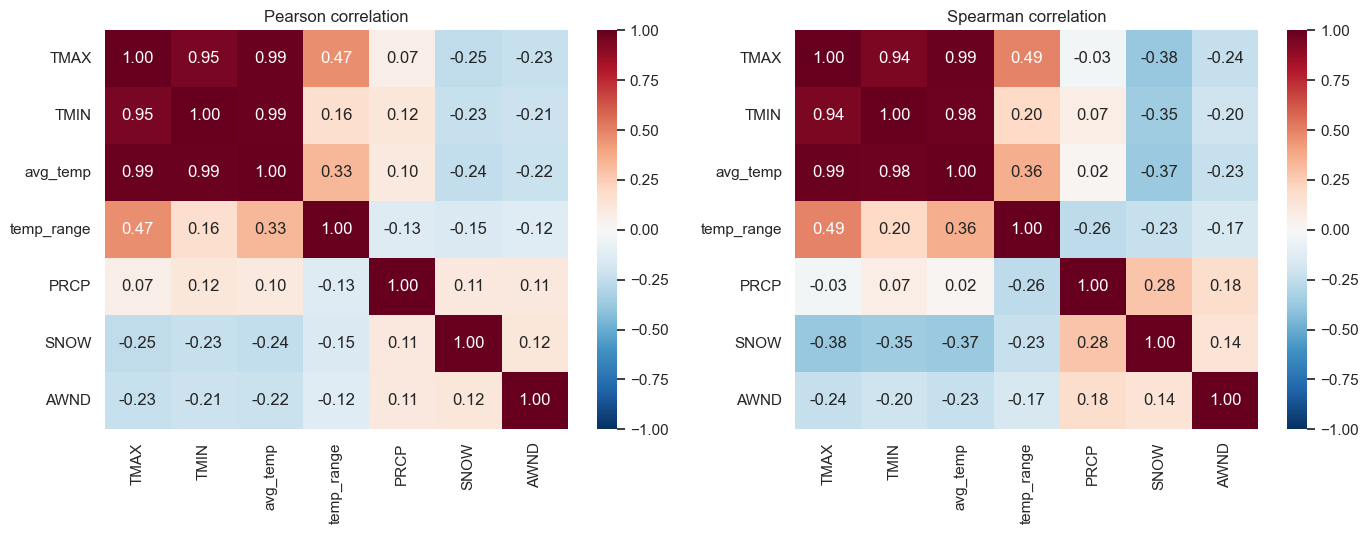

In [26]:
corr_cols = ["TMAX", "TMIN", "avg_temp", "temp_range", "PRCP", "SNOW", "AWND"]
pearson_corr = weather[corr_cols].corr(method="pearson")
spearman_corr = weather[corr_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title("Pearson correlation")
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title("Spearman correlation")
plt.tight_layout()
plt.show()

In [27]:
high_corr_pairs = []
for i, c1 in enumerate(corr_cols):
    for c2 in corr_cols[i+1:]:
        r = pearson_corr.loc[c1, c2]
        if abs(r) > 0.9:
            high_corr_pairs.append((c1, c2, round(r, 3)))

print("Pairs with |Pearson r| > 0.9 (redundancy candidates for Phase 14 feature selection):")
for c1, c2, r in high_corr_pairs:
    print(f"  {c1} <-> {c2}: r={r}")

Pairs with |Pearson r| > 0.9 (redundancy candidates for Phase 14 feature selection):
  TMAX <-> TMIN: r=0.949
  TMAX <-> avg_temp: r=0.988
  TMIN <-> avg_temp: r=0.986


**Redundancy note for Phase 14:** `TMAX`/`TMIN`/`avg_temp` will be
highly collinear by construction — plan to carry `avg_temp` (+ maybe
`temp_range`) as the model feature rather than all three raw columns, and
document that choice in `feature_metadata.csv` when the modeling dataset is
assembled (07).

## 8. Time-series structure: decomposition, stationarity, autocorrelation

`avg_temp` is the clearest seasonal series here — decompose it into trend /
seasonal / residual, then check stationarity and autocorrelation. This
mirrors what Phase 11's crime lag/rolling features will need to reason about
on the crime side, so establishing the weather series' own structure first
gives a reference point.

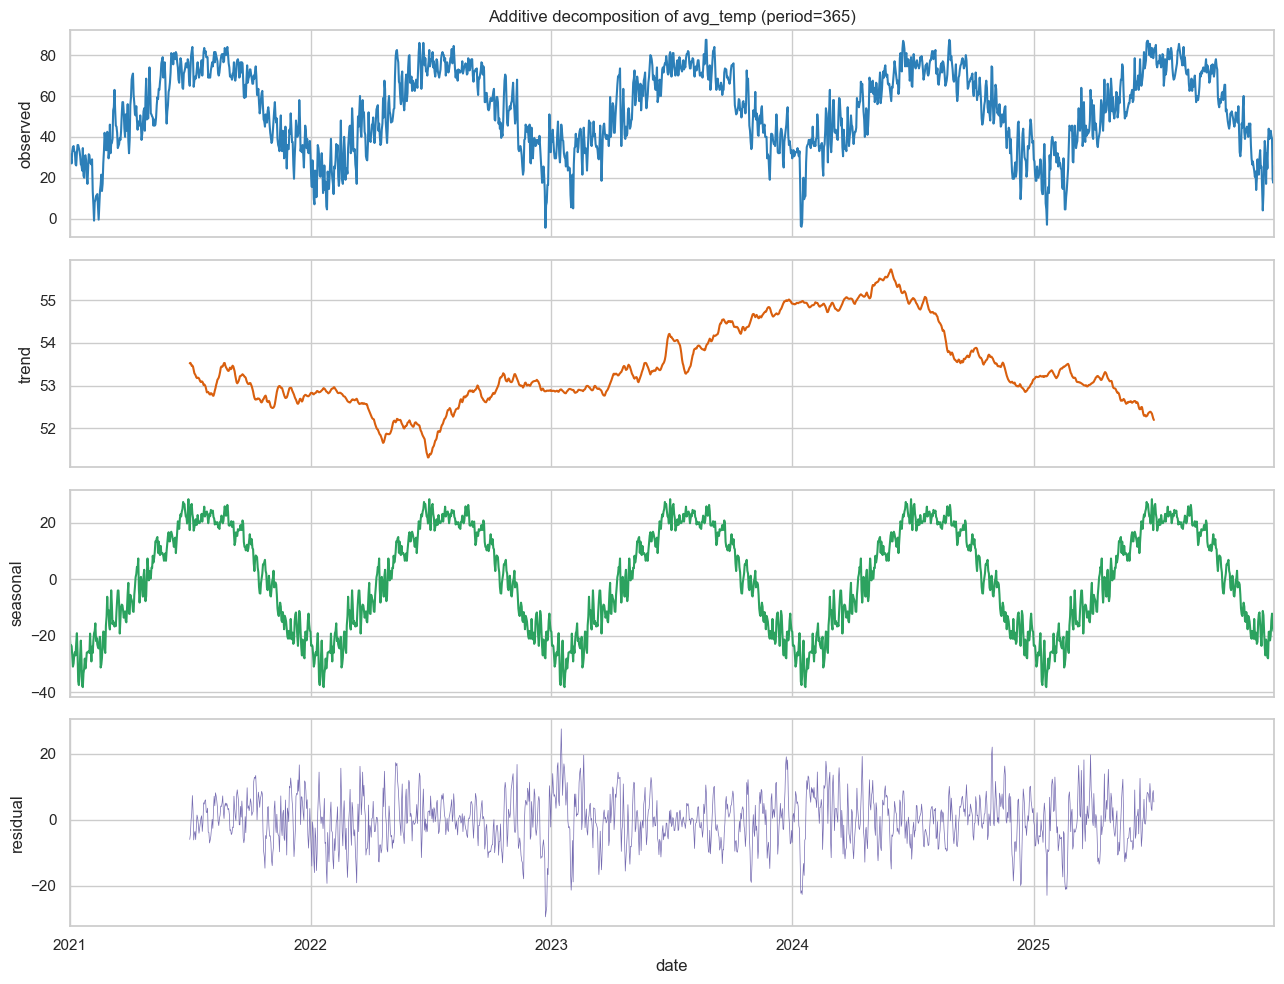

In [28]:
ts = weather.set_index("date")["avg_temp"].asfreq("D")
decomposition = seasonal_decompose(ts, model="additive", period=365)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], color="#2c7fb8"); axes[0].set_ylabel("observed")
decomposition.trend.plot(ax=axes[1], color="#d95f0e"); axes[1].set_ylabel("trend")
decomposition.seasonal.plot(ax=axes[2], color="#2ca25f"); axes[2].set_ylabel("seasonal")
decomposition.resid.plot(ax=axes[3], color="#756bb1", lw=0.5); axes[3].set_ylabel("residual")
axes[0].set_title("Additive decomposition of avg_temp (period=365)")
plt.tight_layout()
plt.show()

In [29]:
adf_stat, adf_p, *_ = adfuller(ts.dropna())
print(f"ADF statistic: {adf_stat:.3f}, p-value: {adf_p:.4f}")
verdict = "stationary" if adf_p < 0.05 else "non-stationary"
print(f"-> raw avg_temp series is {verdict} at alpha=0.05 (expected: strong seasonality makes the raw series non-stationary; that's normal for a temperature series, not a defect).")

ADF statistic: -2.736, p-value: 0.0680
-> raw avg_temp series is non-stationary at alpha=0.05 (expected: strong seasonality makes the raw series non-stationary; that's normal for a temperature series, not a defect).


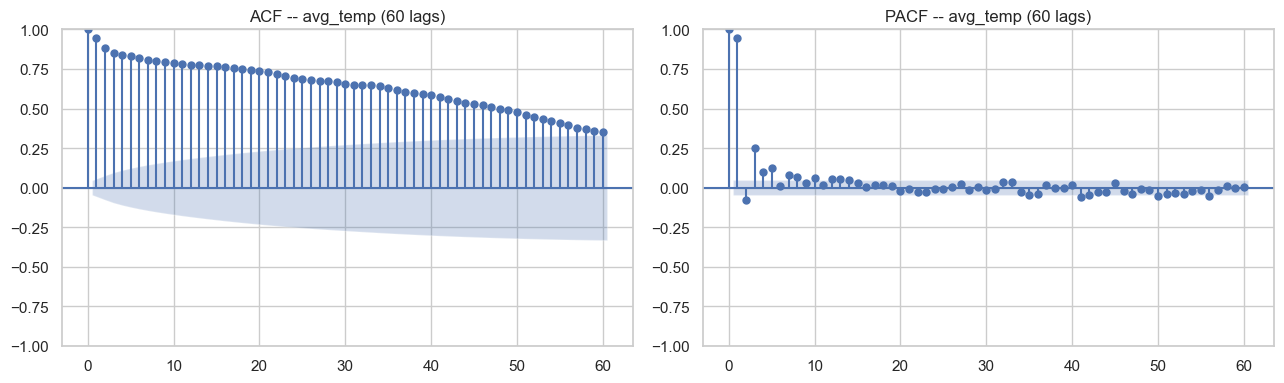

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(ts.dropna(), lags=60, ax=axes[0])
axes[0].set_title("ACF -- avg_temp (60 lags)")
plot_pacf(ts.dropna(), lags=60, ax=axes[1], method="ywm")
axes[1].set_title("PACF -- avg_temp (60 lags)")
plt.tight_layout()
plt.show()

**Reading:** strong, slowly-decaying autocorrelation at short lags is
expected for a seasonal daily series (today's temperature is close to
yesterday's) and is the same structural reason Phase 11 uses lag/rolling
crime features rather than raw daily counts as predictors — persistence is
real signal, not noise, in a series like this.

### 8.1 Change-point check on the trend component

Does the decomposition's trend line show any abrupt shift, or is year-over-
year variation just noise around a flat trend? A rolling-mean vs full-mean
z-score flags candidate change points without fitting a dedicated
change-point model (proportionate to what a weather-only notebook needs).

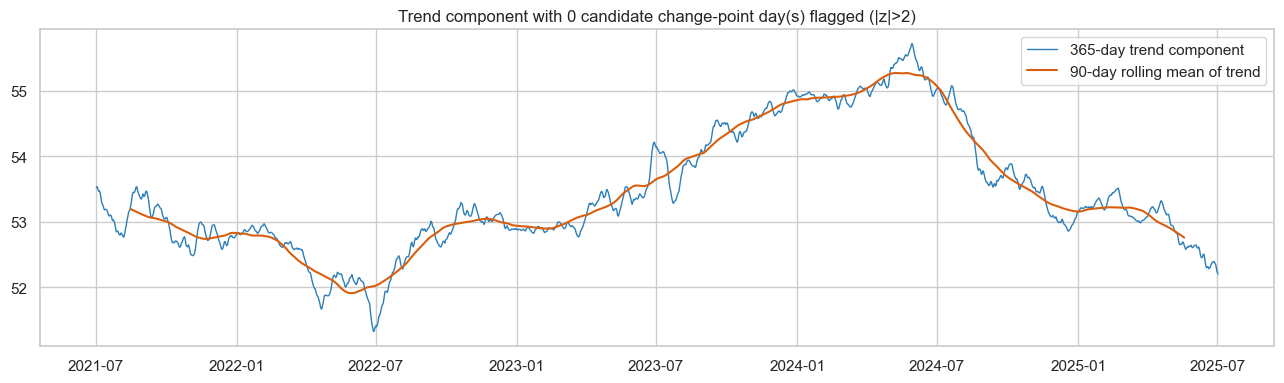

0 day(s) flagged out of 1462 -- no material regime shift detected


In [31]:
trend = decomposition.trend.dropna()
rolling_90 = trend.rolling(90, center=True).mean()
z = (rolling_90 - rolling_90.mean()) / rolling_90.std()
candidate_points = z[z.abs() > 2]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(trend.index, trend.values, color="#2c7fb8", lw=1, label="365-day trend component")
ax.plot(rolling_90.index, rolling_90.values, color="#d95f0e", lw=1.5, label="90-day rolling mean of trend")
for dt in candidate_points.index:
    ax.axvline(dt, color="crimson", alpha=0.15, lw=1)
ax.set_title(f"Trend component with {len(candidate_points)} candidate change-point day(s) flagged (|z|>2)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"{len(candidate_points)} day(s) flagged out of {len(trend)} -- "
      f"{'no material regime shift detected' if len(candidate_points) / len(trend) < 0.02 else 'material shift -- inspect dates below'}")
if len(candidate_points) / len(trend) >= 0.02:
    print(candidate_points.index.tolist())

## 9. Multivariate outlier check

Section 4's IQR pass looked at each column alone. A day can look normal on
every single variable and still be a joint outlier (e.g. warm *and* heavy
snow simultaneously — physically odd, not extreme on either axis alone).
Mahalanobis distance on the (mostly independent) weather variables catches
that.

In [32]:
from scipy.spatial.distance import mahalanobis

mv_cols = ["avg_temp", "temp_range", "PRCP", "SNOW", "AWND"]
X = weather[mv_cols].dropna().values
cov = np.cov(X, rowvar=False)
inv_cov = np.linalg.pinv(cov)
mean_vec = X.mean(axis=0)

mdist = np.array([mahalanobis(row, mean_vec, inv_cov) for row in X])
# Mahalanobis distance^2 ~ chi-square(df=n_features) under multivariate normality
threshold = np.sqrt(stats.chi2.ppf(0.999, df=len(mv_cols)))

mv_outliers = weather.loc[weather[mv_cols].dropna().index].copy()
mv_outliers["mahalanobis_dist"] = mdist
flagged = mv_outliers[mv_outliers["mahalanobis_dist"] > threshold].sort_values("mahalanobis_dist", ascending=False)

print(f"chi-square(df={len(mv_cols)}) 99.9th pct threshold: {threshold:.2f}")
print(f"{len(flagged)} day(s) flagged as multivariate outliers out of {len(mv_outliers)}")
flagged[["date"] + mv_cols + ["mahalanobis_dist"]].head(10)

chi-square(df=5) 99.9th pct threshold: 4.53
51 day(s) flagged as multivariate outliers out of 1826


,date,avg_temp,temp_range,PRCP,SNOW,AWND,mahalanobis_dist
1793,2025-11-29,28.0,6,0.69,8.4,9.84,16.684311
912,2023-07-02,69.5,7,3.35,0.0,8.95,13.534180
30,2021-01-31,31.0,2,0.29,6.3,16.78,12.524470
45,2021-02-15,6.0,12,0.19,6.1,16.11,11.943662
397,2022-02-02,24.5,17,0.30,5.4,15.43,10.639056
25,2021-01-26,28.5,7,0.48,5.3,17.67,10.458192
1106,2024-01-12,33.0,6,0.77,4.7,13.42,9.332820
1801,2025-12-07,23.0,14,0.35,4.6,11.41,8.955350
29,2021-01-30,31.5,5,0.36,4.5,16.55,8.889429
38,2021-02-08,8.0,14,0.08,3.9,4.03,8.046126


**Note:** these are *statistical* outliers under a normality
approximation the zero-inflated `PRCP`/`SNOW` columns don't fully satisfy —
treat this list as candidates worth a manual look (e.g. cross-checking
against the crime data in notebook 06 for those specific dates), not as rows
to drop. Nothing gets removed here; this notebook only flags.

## 10. Persist cleaned + feature-engineered weather data

Saved to `data/interim/weather_cleaned.parquet` per the blueprint's Phase 7
deliverable path. This is the frame notebook 06 (`crime_weather_analysis`)
will load and merge against the daily crime aggregate on `date`.

In [33]:
weather_out = weather.drop(columns=["year", "month", "doy", "dow", "is_weekend"])
weather_out.to_parquet(INTERIM_WEATHER_PATH, index=False)
print(f"saved {len(weather_out)} rows x {weather_out.shape[1]} cols -> {INTERIM_WEATHER_PATH}")
weather_out.dtypes.to_frame("dtype")

saved 1826 rows x 15 cols -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\data\interim\weather_cleaned.parquet


,dtype
date,datetime64[ns]
AWND,float64
station,object
SNOW,float64
TMAX,int64
TMIN,int64
PRCP,float64
avg_temp,float64
temp_range,int64
is_rain,bool


In [34]:
reloaded = pd.read_parquet(INTERIM_WEATHER_PATH)
assert reloaded.shape == weather_out.shape
assert reloaded["date"].is_unique
assert reloaded["date"].min() == pd.Timestamp(config.START_DATE)
assert reloaded["date"].max() == pd.Timestamp(config.END_DATE)
print("round-trip verified: saved parquet matches in-memory frame, full 2021-2025 coverage intact.")

round-trip verified: saved parquet matches in-memory frame, full 2021-2025 coverage intact.


## 11. Findings

**Top findings**
- Month explains 79.3% of variance in `avg_temp` (Kruskal-Wallis eta-squared,
  p≈2.7e-310) — the expected large, highly significant seasonal effect.
- Precipitation is comparatively flat across the year: month explains only
  1.3% of `PRCP` variance (small effect, p=0.032) versus 7.1% for `SNOW` and
  10.2% for `AWND` — rain doesn't concentrate seasonally here the way
  temperature and snow do.
- No weekday/weekend weather difference (Mann-Whitney p=0.437) — confirms
  Phase 18's `temp x weekend` / `rain x weekend` interaction terms will
  reflect human behavior, not a hidden weather-collection artifact.
- `TMAX`/`TMIN`/`avg_temp` are highly collinear by construction
  (r=0.949–0.988) — expected, but a real Phase 14 constraint.
- 51 of 1,826 days (2.8%) flagged as multivariate outliers under a 99.9th-
  percentile Mahalanobis threshold — higher than the nominal 0.1% because
  `PRCP`/`SNOW`'s zero-inflated distribution violates the underlying
  normality approximation; treat the flagged list as candidates to
  cross-reference against crime dates in notebook 06, not as confirmed
  anomalies.
- No NOAA sentinel values were present in this station's 2021–2025 pull —
  zero replaced across all six numeric columns (Section 2).
- Zero missing calendar days: exactly 1,826 rows for 2021-01-01 through
  2025-12-31, one per day (Section 2.2). Raw `avg_temp` series is
  non-stationary (ADF p=0.068) as expected for an untransformed seasonal
  series — not a defect, just context for anyone lag-differencing it later.

**Quality issues to address**
- `TAVG` is entirely absent from this station's extract — `avg_temp` is
  100% computed as `(TMAX+TMIN)/2`, not a station reading. Carried forward
  as a documented limitation, already noted in `weather_features.py` and
  the blueprint's known-limitations list.
- `TMAX`/`TMIN`/`avg_temp` are highly collinear by construction (Section 7)
  — Phase 14 feature selection should not include all three as separate
  model inputs.

**Hypotheses worth testing (in notebook 06, against crime)**
- Extreme-heat days (`is_extreme_heat`) associate with elevated violent-crime
  counts relative to non-extreme days.
- Heavy-snow days (`is_heavy_snow`) associate with *reduced* overall crime
  counts (mobility friction hypothesis).
- The `rain x weekend` and `snow x night` interactions proposed in Phase 18
  are worth testing given Section 6.1 confirms no weekday/weekend weather
  measurement artifact to control for first.

**Recommended next steps**
- Proceed to `06_crime_weather_analysis.ipynb`: merge this cleaned frame
  against the daily community-area crime aggregate on `date`, then run the
  Pearson/Spearman + Mann-Whitney/Kruskal-Wallis battery from Phase 10
  against actual crime counts.
- Carry `avg_temp`, `temp_range`, and the five threshold flags forward as
  the weather feature set for Phase 14; drop raw `TMAX`/`TMIN` from the
  model matrix given the collinearity noted above (keep them in the interim
  parquet for transparency, exclude at model-matrix assembly in notebook 07).
